# Hidden CKD

#### Features
The following are the features used in this study in order of appearance
- Date of event: Date of the screening
- Gender: Gender of the patient (M: Male, F: Female)
- Ethnicity: The ethnicity of the participant
- Age: Age of the patient (years)
- Height (cm): Height of the participant in cm
- Weight (kg): Weight of the participant in kg
- BMI: BMI of the participant
- BMI Category: Classification of the particpant BMI according to NICE guidelines
- Systolic, Diastolic: The systolic and diastolic of the partcipants
- Pulse Pressure: 
- BP Category: Classification of the particpant BP according to NICE guidelines
- Has High BP:
- Has Diabetes
- Has Kidney Disease
- On BP Medication?
- On Diabetes Medication?
- On Cholesterol Medication?
- On Other Medication?
- Family History of Kidney Disease: Whether the patient has a family history of kidney disease (Definitely Yes, Definitely Not, Not Sure)
- uACR: Urine albumin to creatinine ratio of the participants as measured using a urine dipstick (Normal, Abnormal, High Abnormal)
- CKD Risk: A calculation of CKD risk by combining research findings

This is how CKD risk is calculated

low risk = sys<140, dia<90, uACR='Normal', Has_Diabetes=False or Family_KD=False<br>
moderate risk = sys<140, dia<90, uACR='Abnormal', Has_Diabetes=True or Family_KD=True<br>
high risk = sys>=180, dia>=120, uACR='High Abnormal', Has_Diabetes=False or Family_KD=False<br>

In [55]:
import numpy as np
import pandas as pd
from src.config import PROCESSED_DATA_DIR

In [56]:
filename = PROCESSED_DATA_DIR / 'hidden_ckd_processed.csv'
df = pd.read_csv(filename)
df.head()

,Date,Gender,Ethnicity,S_Ethnicity,Ethnicity_Black,DOB,Age,Age_Category,Height,Weight,...,Has_Diabetes,Has_KD,Has_HD,BP_Meds,Diabetes_Meds,Cholesterol_Meds,Other_Meds,Family_KD,uACR,CKD_Risk
0,23/10/2022,Male,Black Caribbean,Black,True,21/05/1946,76.5,>70,161.0,64.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate
1,23/10/2022,Male,Black African (West Africa),Black,True,25/01/1970,52.8,41-55,163.0,78.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate
2,26/08/2023,Male,Black Caribbean,Black,True,14/07/2005,18.1,<25,167.0,91.0,...,False,False,False,False,False,False,False,Definitely not,Normal,Low
3,28/04/2023,Male,Black Caribbean,Black,True,25/04/1969,54.0,41-55,168.0,87.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate
4,06/11/2022,Female,Black African (West Africa),Black,True,03/11/1979,43.0,41-55,187.0,109.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate


## ML Models (without Using Blood Pressure Readings)

In [57]:
# Import modules
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer
import joblib
from src.config import MODELS_DIR

In [58]:
from src.utils.model_utils import (resample_data, stratified_split, random_split,
                                   load_model, evaluate_model)
from src.utils.models import (train_ensemble1, train_ensemble2, train_ensemble3, train_gnb,
                              train_knn, train_lr, train_rf, train_xg)

In [59]:
features = [
    'Age',
    'Height',
    'Weight',
    'S_Ethnicity',
    'Family_KD',
    'Gender',
    'Has_Hpt',
    'Has_Diabetes',
]

# Import processed data
X = df[features]


# Creating preprocessing pipelines for both numeric and nominal and ordinal data.
num_features = ['Age', 'Height', 'Weight']
num_transformer = Pipeline(steps=[
    ('power_transform', PowerTransformer(method='yeo-johnson'))])

nom_features = ['S_Ethnicity', 'Family_KD']
nom_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])

ord_features = ['Gender', 'Has_Hpt', 'Has_Diabetes']

gender_values = [['Female', 'Male']]
binary_values = [[False, True]]

ord_transformer = make_column_transformer(
    (OrdinalEncoder(categories=gender_values), ['Gender']),
    (OrdinalEncoder(categories=binary_values), ['Has_Hpt']),
    (OrdinalEncoder(categories=binary_values), ['Has_Diabetes']),
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('nom', nom_transformer, nom_features),
        ('ord', ord_transformer, ord_features)])

In [60]:
# Fit preprocessor
preprocessor.fit(X)
X = preprocessor.transform(X)

preprocessor_filename = 'basic_preprocessor_nobp.pkl'
joblib.dump(preprocessor, MODELS_DIR / preprocessor_filename)

['/Users/Edward/Documents/GitHub/hidden-ckd/models/basic_preprocessor_nobp.pkl']

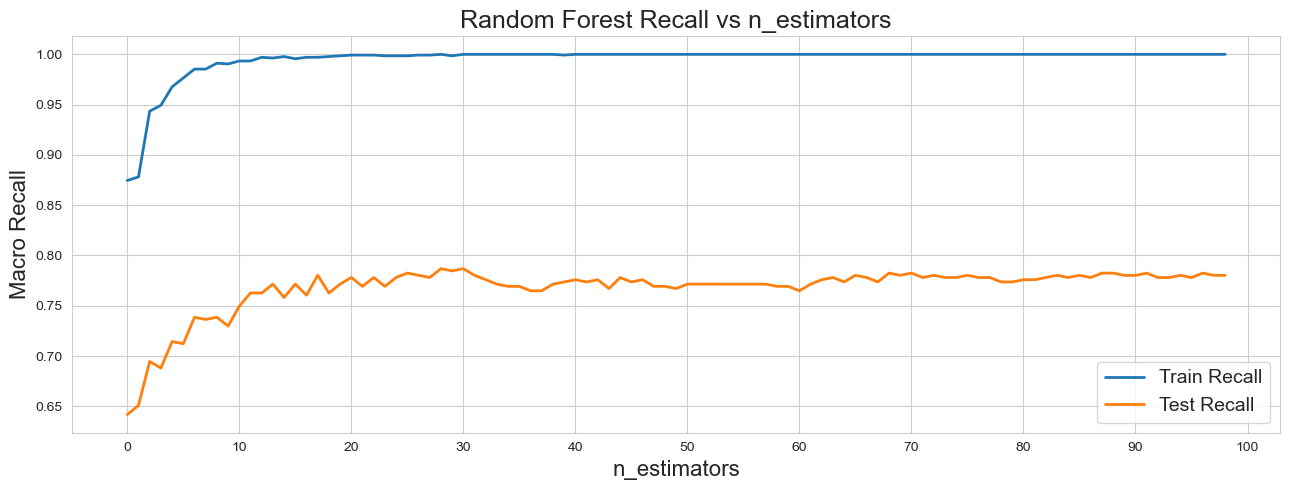

Max test recall: 0.7869 at 31 estimators


In [61]:
# Load features, target, and target encoding
X = pd.DataFrame(data=X)
y = df['CKD_Risk']
target_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}

# Correct class imbalance
X_over, y_over = resample_data(X, y, target_mapping)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = stratified_split(X_over, y_over)
#X_train, X_test, y_train, y_test = random_split(X_over, y_over)

# Train Model
model_filename = 'classifier_nobp.pkl'
#model = train_xg(X_train, y_train, model_filename)
model = train_rf(X_train, X_test, y_train, y_test, model_filename)
#model = train_lr(X_train, y_train, model_filename)
#model = train_knn(X_train, y_train, model_filename)
#model = train_gnb(X_train, y_train, model_filename)
#model = train_ensemble1(X_train, y_train, model_filename)
#model = train_ensemble2(X_train, y_train, model_filename)
#model = train_ensemble3(X_train, y_train, model_filename)


Accuracy: 0.7868131868131868

Classification Report:
               precision    recall  f1-score   support

         Low       0.72      0.81      0.77       151
    Moderate       0.75      0.72      0.74       152
        High       0.91      0.82      0.86       152

    accuracy                           0.79       455
   macro avg       0.79      0.79      0.79       455
weighted avg       0.79      0.79      0.79       455



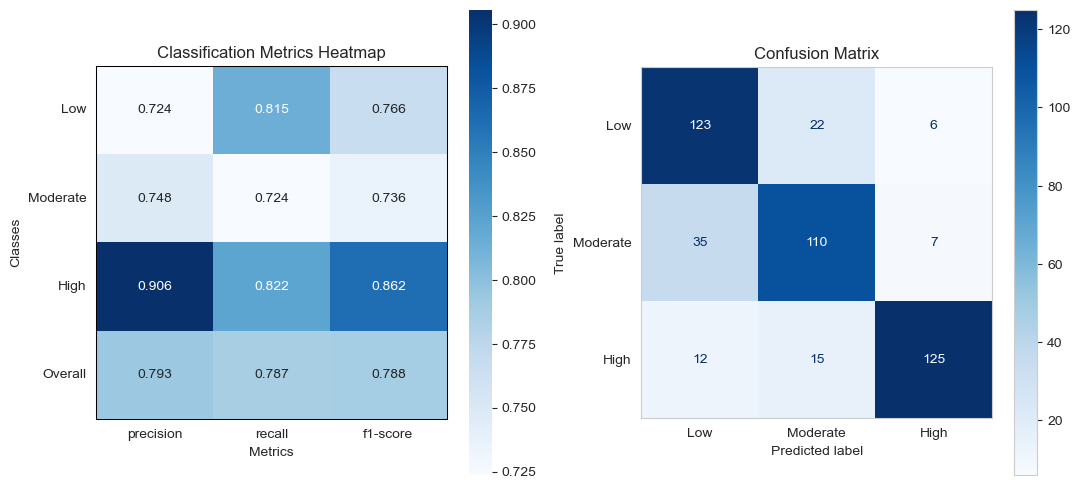

In [62]:
# Import modules
from src.utils.model_utils import load_model, evaluate_model

# Load test data
target_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}

# Load model
model = load_model(model_filename)

# Evaluate model
evaluate_model(model, X_test, y_test, target_mapping)

In [69]:
data = pd.DataFrame([{
    'Age': 40,
    'Height': 158,
    'Weight': 120,
    'S_Ethnicity': 'Black',
    'Family_KD': 'Definitely yes',
    'Gender': 'Male',
    'Has_Hpt': True,
    'Has_Diabetes': True,
}])

# Run pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', model)
])

# Prediction
prediction = full_pipeline.predict(data)
print("Prediction:", prediction)

target_mapping = {0:'Low', 1:'Moderate', 2:'High'}
probabilities = full_pipeline.predict_proba(data)
for i, probs in enumerate(probabilities):
    for cls, prob in enumerate(probs):
        print(f"  {target_mapping.get(cls)} Risk probability: {prob:.4f}")


Prediction: [1]
  Low Risk probability: 0.0968
  Moderate Risk probability: 0.5161
  High Risk probability: 0.3871
